In [2]:
import pandas as pd
import os
import re
import matplotlib.pyplot as plt
import numpy as np

In [3]:
def group_data(dir_path: str):
    # Load the results
    files_to_read = [file for file in os.listdir(dir_path) if file.endswith('.csv')]
    pattern = r'agent_stats_run_(\d+)_ctr_(\d+\.?\d*)_alpha_(\d+\.?\d*)'
    results = pd.DataFrame()
    for file in files_to_read:
        match = re.search(pattern, file)
        if match:
            soglia_ctr = float(match.group(2))
            alpha = float(match.group(3))
            
            curr_results = pd.read_csv(dir_path + file)

            curr_results['soglia_ctr'] = soglia_ctr
            curr_results['alpha'] = alpha

            results = pd.concat([results, curr_results])
    # Prima raggruppo per Run e Iteration per avere il dato aggregato per ogni iterazione
    grouped_results_run_iter = results.groupby(['soglia_ctr','alpha', 'Run', 'Iteration']) \
        .agg({'clicks': 'sum', 'impressions': 'sum', 'true_clicks': 'sum', 'est_clicks': 'sum', 'est_impressions': 'sum', 'publisher':'nunique'}) \
        .reset_index()
    grouped_results_run_iter['ctr'] = grouped_results_run_iter['clicks'] / grouped_results_run_iter['impressions']
    grouped_results_run_iter['true_ctr'] = grouped_results_run_iter['true_clicks'] / grouped_results_run_iter['impressions']
    # Valori medi sulle run per ogni iterazione
    grouped_results = grouped_results_run_iter.groupby(['soglia_ctr','alpha', 'Iteration']).mean().reset_index()
    # intervallo di confidenza click
    grouped_results['clicks_std'] = grouped_results_run_iter.groupby(['soglia_ctr','alpha', 'Iteration']).std().reset_index()['clicks']
    grouped_results['clicks_ci'] = 1.96 * grouped_results['clicks_std'] / np.sqrt(grouped_results_run_iter.groupby(['soglia_ctr','alpha', 'Iteration']).count().reset_index()['clicks'])
    # intervallo di confidenza true_clicks
    grouped_results['true_clicks_std'] = grouped_results_run_iter.groupby(['soglia_ctr','alpha', 'Iteration']).std().reset_index()['true_clicks']
    grouped_results['true_clicks_ci'] = 1.96 * grouped_results['true_clicks_std'] / np.sqrt(grouped_results_run_iter.groupby(['soglia_ctr','alpha', 'Iteration']).count().reset_index()['true_clicks'])
    # intervallo di confidenza impressions
    grouped_results['impressions_std'] = grouped_results_run_iter.groupby(['soglia_ctr','alpha', 'Iteration']).std().reset_index()['impressions']
    grouped_results['impressions_ci'] = 1.96 * grouped_results['impressions_std'] / np.sqrt(grouped_results_run_iter.groupby(['soglia_ctr','alpha', 'Iteration']).count().reset_index()['impressions'])
    # intervallo di confidenza CTR e True CTR
    grouped_results['ctr_std'] = grouped_results_run_iter.groupby(['soglia_ctr','alpha', 'Iteration']).std().reset_index()['ctr']
    grouped_results['ctr_ci'] = 1.96 * grouped_results['ctr_std'] / np.sqrt(grouped_results_run_iter.groupby(['soglia_ctr','alpha', 'Iteration']).count().reset_index()['ctr'])
    grouped_results['true_ctr_std'] = grouped_results_run_iter.groupby(['soglia_ctr','alpha', 'Iteration']).std().reset_index()['true_ctr']
    grouped_results['true_ctr_ci'] = 1.96 * grouped_results['true_ctr_std'] / np.sqrt(grouped_results_run_iter.groupby(['soglia_ctr','alpha', 'Iteration']).count().reset_index()['true_ctr'])
    # estimated clicks
    grouped_results['est_clicks_std'] = grouped_results_run_iter.groupby(['soglia_ctr','alpha', 'Iteration']).std().reset_index()['est_clicks']
    grouped_results['est_clicks_ci'] = 1.96 * grouped_results['est_clicks_std'] / np.sqrt(grouped_results_run_iter.groupby(['soglia_ctr','alpha', 'Iteration']).count().reset_index()['est_clicks'])
    # estimated impressions
    grouped_results['est_impressions_std'] = grouped_results_run_iter.groupby(['soglia_ctr','alpha', 'Iteration']).std().reset_index()['est_impressions']
    grouped_results['est_impressions_ci'] = 1.96 * grouped_results['est_impressions_std'] / np.sqrt(grouped_results_run_iter.groupby(['soglia_ctr','alpha', 'Iteration']).count().reset_index()['est_impressions'])
    return grouped_results

In [4]:
def group_data_sw(dir_path: str):
    # Load the results
    files_to_read = [file for file in os.listdir(dir_path) if file.endswith('.csv')]
    pattern = r'agent_stats_run_(\d+)_ctr_(\d+\.?\d*)_alpha_(\d+\.?\d*)_ws_(\d+)'
    results = pd.DataFrame()
    for file in files_to_read:
        match = re.search(pattern, file)
        if match:
            alpha = float(match.group(3))
            ws = int(match.group(4))
            curr_results = pd.read_csv(dir_path + file)
            curr_results['alpha'] = alpha
            curr_results['ws'] = ws
            results = pd.concat([results, curr_results])
    # Prima raggruppo per Run e Iteration per avere il dato aggregato per ogni iterazione
    grouped_results_run_iter = results.groupby(['ws', 'alpha', 'Run', 'Iteration']) \
        .agg({'clicks': 'sum', 'impressions': 'sum', 'true_clicks': 'sum', 'publisher':'nunique'}) \
        .reset_index()
    grouped_results_run_iter['ctr'] = grouped_results_run_iter['clicks'] / grouped_results_run_iter['impressions']
    grouped_results_run_iter['true_ctr'] = grouped_results_run_iter['true_clicks'] / grouped_results_run_iter['impressions']
    # Valori medi sulle run per ogni iterazione
    grouped_results = grouped_results_run_iter.groupby(['ws', 'alpha', 'Iteration']).mean().reset_index()
    # intervallo di confidenza click
    grouped_results['clicks_std'] = grouped_results_run_iter.groupby(['ws', 'alpha', 'Iteration']).std().reset_index()['clicks']
    grouped_results['clicks_ci'] = 1.96 * grouped_results['clicks_std'] / np.sqrt(grouped_results_run_iter.groupby(['ws', 'alpha', 'Iteration']).count().reset_index()['clicks'])
    # intervallo di confidenza true_clicks
    grouped_results['true_clicks_std'] = grouped_results_run_iter.groupby(['ws', 'alpha', 'Iteration']).std().reset_index()['true_clicks']
    grouped_results['true_clicks_ci'] = 1.96 * grouped_results['true_clicks_std'] / np.sqrt(grouped_results_run_iter.groupby(['ws', 'alpha', 'Iteration']).count().reset_index()['true_clicks'])
    # intervallo di confidenza impressions
    grouped_results['impressions_std'] = grouped_results_run_iter.groupby(['ws', 'alpha', 'Iteration']).std().reset_index()['impressions']
    grouped_results['impressions_ci'] = 1.96 * grouped_results['impressions_std'] / np.sqrt(grouped_results_run_iter.groupby(['ws', 'alpha', 'Iteration']).count().reset_index()['impressions'])
     # intervallo di confidenza CTR e True CTR
    grouped_results['ctr_std'] = grouped_results_run_iter.groupby(['ws', 'alpha', 'Iteration']).std().reset_index()['ctr']
    grouped_results['ctr_ci'] = 1.96 * grouped_results['ctr_std'] / np.sqrt(grouped_results_run_iter.groupby(['ws', 'alpha', 'Iteration']).count().reset_index()['ctr'])
    grouped_results['true_ctr_std'] = grouped_results_run_iter.groupby(['ws', 'alpha', 'Iteration']).std().reset_index()['true_ctr']
    grouped_results['true_ctr_ci'] = 1.96 * grouped_results['true_ctr_std'] / np.sqrt(grouped_results_run_iter.groupby(['ws', 'alpha', 'Iteration']).count().reset_index()['true_ctr'])
    return grouped_results

In [5]:
def group_data_log(dir_path: str):
    # Load the results
    files_to_read = [file for file in os.listdir(dir_path) if file.endswith('.csv')]
    pattern = r'agent_stats_run_(\d+)_ctr_(\d+\.?\d*)_alpha_(\d+\.?\d*)'
    results = pd.DataFrame()
    for file in files_to_read:
        match = re.search(pattern, file)
        if match:
            ctr = float(match.group(2))
            alpha = float(match.group(3))

            curr_results = pd.read_csv(dir_path + file)

            curr_results['soglia_ctr'] = ctr
            curr_results['alpha'] = alpha

            results = pd.concat([results, curr_results])
    groupby_columns = ['soglia_ctr', 'alpha', 'Iteration']
    results['clicks'] = results['clicks'].apply(lambda x: np.exp(x))
    results['impressions'] = results['impressions'].apply(lambda x: np.exp(x))
    results['est_clicks'] = results['est_clicks'].apply(lambda x: np.exp(x))
    results['est_impressions'] = results['est_impressions'].apply(lambda x: np.exp(x))
    # Prima raggruppo per Run e Iteration per avere il dato aggregato per ogni iterazione
    grouped_results_run_iter = results.groupby(['soglia_ctr', 'alpha', 'Run', 'Iteration']) \
        .agg({'clicks': 'sum', 'impressions': 'sum', 'est_clicks': 'sum', 'est_impressions': 'sum', 'publisher':'nunique'}) \
        .reset_index()
    # Valori medi sulle run per ogni iterazione
    grouped_results = grouped_results_run_iter.groupby(groupby_columns).mean().reset_index()
    # intervallo di confidenza click
    grouped_results['clicks_std'] = grouped_results_run_iter.groupby(groupby_columns).std().reset_index()['clicks']
    grouped_results['clicks_ci'] = 1.96 * grouped_results['clicks_std'] / np.sqrt(grouped_results_run_iter.groupby(groupby_columns).count().reset_index()['clicks'])
    # intervallo di confidenza impressions
    grouped_results['impressions_std'] = grouped_results_run_iter.groupby(groupby_columns).std().reset_index()['impressions']
    grouped_results['impressions_ci'] = 1.96 * grouped_results['impressions_std'] / np.sqrt(grouped_results_run_iter.groupby(groupby_columns).count().reset_index()['impressions'])
    # Calcolo CTR e True CTR
    grouped_results['ctr'] = grouped_results['clicks'] / grouped_results['impressions']
    # estimated clicks
    grouped_results['est_clicks_std'] = grouped_results_run_iter.groupby(groupby_columns).std().reset_index()['est_clicks']
    grouped_results['est_clicks_ci'] = 1.96 * grouped_results['est_clicks_std'] / np.sqrt(grouped_results_run_iter.groupby(groupby_columns).count().reset_index()['est_clicks'])
    # estimated impressions
    grouped_results['est_impressions_std'] = grouped_results_run_iter.groupby(groupby_columns).std().reset_index()['est_impressions']
    grouped_results['est_impressions_ci'] = 1.96 * grouped_results['est_impressions_std'] / np.sqrt(grouped_results_run_iter.groupby(groupby_columns).count().reset_index()['est_impressions'])
    return grouped_results

In [6]:
def plot_mul_gr_soglia(gr_res_models, iteration=1, quantity='clicks', optimal_quantity=None, alpha_to_exclude=[]):
    unique_soglie_ctr = set()
    for gr_res in gr_res_models.values():
        unique_soglie_ctr.update(gr_res['soglia_ctr'].unique())
    # Prendo i valori unici di alpha da tutti i modelli
    unique_alphas = set()
    for gr_res in gr_res_models.values():
        unique_alphas.update(gr_res['alpha'].unique())
    for soglia_ctr in unique_soglie_ctr:
        plt.figure(figsize=(10, 6))
        for alpha in unique_alphas:
            if alpha_to_exclude and alpha in alpha_to_exclude:
                continue
            for model, gr_res in gr_res_models.items():
                if alpha not in gr_res['alpha'].unique():
                    continue
                model_data = gr_res[(gr_res['Iteration']>iteration)&(gr_res['alpha'] == alpha)&(gr_res['soglia_ctr'] == soglia_ctr)]
                plt.plot(model_data['Iteration'].to_numpy(), model_data[quantity].to_numpy(), label=f'{model} α={alpha}')
                if f'{quantity}_ci' in model_data.columns:
                    plt.fill_between(model_data['Iteration'].to_numpy(), 
                                    model_data[quantity].to_numpy() -  model_data[f'{quantity}_ci'].to_numpy(), 
                                    model_data[quantity].to_numpy() +  model_data[f'{quantity}_ci'].to_numpy(), 
                                    alpha=0.5)
        if optimal_quantity:
            plt.axhline(y=optimal_quantity, color='r', linestyle='--', label=f'target {quantity}')
        plt.title(f'{quantity} mediati sulle run dall\'iterazione {iteration + 1} con soglia_ctr={soglia_ctr}')
        plt.xlabel('Iteration')
        plt.ylabel(quantity)
        plt.legend()
        plt.tight_layout()
        plt.show()

In [7]:
def plot_mul_gr(gr_res_models, iteration=1, quantity='clicks', optimal_quantity=None, alpha_to_exclude=[]):
    # Prendo i valori unici di alpha da tutti i modelli
    unique_alphas = set()
    for gr_res in gr_res_models.values():
        unique_alphas.update(gr_res['alpha'].unique())
    plt.figure(figsize=(10, 6))
    for alpha in unique_alphas:
        if alpha_to_exclude and alpha in alpha_to_exclude:
            continue
        for model, gr_res in gr_res_models.items():
            if alpha not in gr_res['alpha'].unique():
                continue
            model_data = gr_res[(gr_res['Iteration']>iteration)&(gr_res['alpha'] == alpha)]
            plt.plot(model_data['Iteration'].to_numpy(), model_data[quantity].to_numpy(), label=f'{model} α={alpha}')
            if f'{quantity}_ci' in model_data.columns:
                plt.fill_between(model_data['Iteration'].to_numpy(), 
                                 model_data[quantity].to_numpy() -  model_data[f'{quantity}_ci'].to_numpy(), 
                                 model_data[quantity].to_numpy() +  model_data[f'{quantity}_ci'].to_numpy(), 
                                 alpha=0.5)
    if optimal_quantity:
        plt.axhline(y=optimal_quantity, color='r', linestyle='--', label=f'target {quantity}')
    plt.title(f'{quantity} mediati sulle run dall\'iterazione {iteration + 1}')
    plt.xlabel('Iteration')
    plt.ylabel(quantity)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [8]:
def plot_mul_gr_sw(gr_res_models, iteration=1, quantity='clicks', optimal_quantity=None, alpha_to_exclude=[]):
    # Prendo i valori unici di alpha da tutti i modelli
    unique_alphas = set()
    for gr_res in gr_res_models.values():
        unique_alphas.update(gr_res['alpha'].unique())
    plt.figure(figsize=(10, 6))
    for alpha in unique_alphas:
        if alpha_to_exclude and alpha in alpha_to_exclude:
            continue
        for model, gr_res in gr_res_models.items():
            model_data = gr_res[(gr_res['Iteration']>iteration)&(gr_res['alpha'] == alpha)]
            if 'ws' in model_data.columns:
                win_sizes = model_data['ws'].unique()
                for ws in win_sizes:
                    curr_data = model_data[model_data['ws'] == ws]
                    plt.plot(curr_data['Iteration'].to_numpy(), curr_data[quantity].to_numpy(), label=f'{model} α={alpha} ws={ws}')
                    if f'{quantity}_ci' in model_data.columns:
                        plt.fill_between(curr_data['Iteration'].to_numpy(), 
                                        curr_data[quantity].to_numpy() -  curr_data[f'{quantity}_ci'].to_numpy(), 
                                        curr_data[quantity].to_numpy() +  curr_data[f'{quantity}_ci'].to_numpy(), 
                                        alpha=0.2)
            else:
                plt.plot(model_data['Iteration'].to_numpy(), model_data[quantity].to_numpy(), label=f'{model} α={alpha}')
                if f'{quantity}_ci' in model_data.columns:
                    plt.fill_between(model_data['Iteration'].to_numpy(), 
                                    model_data[quantity].to_numpy() -  model_data[f'{quantity}_ci'].to_numpy(), 
                                    model_data[quantity].to_numpy() +  model_data[f'{quantity}_ci'].to_numpy(), 
                                    alpha=0.2)
    if optimal_quantity:
        plt.axhline(y=optimal_quantity, color='r', linestyle='--', label=f'optimal {quantity}')
    plt.title(f'{quantity} mediati sulle run dall\'iterazione {iteration + 1}')
    plt.xlabel('Iteration')
    plt.ylabel(quantity)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [27]:
linucb_dir_path = '../results/FP_Truthful_Oracle_sigmoids_linucb_textemb_ctr_0_99_06_12_24/'
linucb_gr_res = group_data(linucb_dir_path)

In [66]:
# Ora il modello non viene allenato con dati di aste che non producono click né impression
linucb_newagent_dir_path = '../results/FP_Truthful_Oracle_sigmoids_linucb_textemb_ctr_0_97_05_12_24_nuovoagent/'
linucb_newagent_gr_res = group_data(linucb_newagent_dir_path)

In [18]:
linucb_logpred_dir_path = '../results/FP_Truthful_Oracle_sigmoids_linucb_textemb_ctr_0_97_05_12_24_logpred/'
linucb_logpred_gr_res = group_data_log(linucb_logpred_dir_path)
linucb_logpred_gr_res = linucb_logpred_gr_res[linucb_logpred_gr_res['Iteration'] <= 400]

In [67]:
linucb_rescaled_dir_path = '../results/FP_Truthful_Oracle_sigmoids_linucb_rescaledtextemb_ctr_0_97_06_12_24/'
linucb_rescaled_gr_res = group_data(linucb_rescaled_dir_path)

In [56]:
cucb_dir_path = '../results/FP_Truthful_Oracle_sigmoids_cucb_textemb_ctr_0_90_06_12_24/'
cucb_gr_res = group_data(cucb_dir_path)
cucb_gr_res = cucb_gr_res[cucb_gr_res['Iteration'] <= 400]

In [68]:
cucb_newagent_dir_path = '../results/FP_Truthful_Oracle_sigmoids_cucb_textemb_ctr_0_97_05_12_24_nuovoagent/'
cucb_newagent_gr_res = group_data(cucb_newagent_dir_path)

In [10]:
sw_cucb_dir_path = '../results/FP_IPS_Oracle_sigmoids_swcucb/'
sw_cucb_gr_res = group_data_sw(sw_cucb_dir_path)

In [22]:
cucb_gr_res = cucb_gr_res[cucb_gr_res['Iteration'] <= 500]

In [98]:
cucb_noaddpub_dir_path = '../results/FP_Truthful_Oracle_sigmoids_cucb_textemb_18_11_24/'
cucb_noaddpub_gr_res = group_data(cucb_noaddpub_dir_path)

In [101]:
linucb_noaddpub_dir_path = '../results/FP_Truthful_Oracle_sigmoids_linucb_textemb_18_11_24/'
linucb_noaddpub_gr_res = group_data(linucb_noaddpub_dir_path)

In [69]:
models = {
    # 'LinUCB': linucb_gr_res,
    'LinUCB': linucb_newagent_gr_res,
    # 'LinUCB LogPred': linucb_logpred_gr_res,
    'LinUCB Rescaled': linucb_rescaled_gr_res,
    # 'LinUCB No add pub': linucb_noaddpub_gr_res,
    # 'CUCB': cucb_gr_res,
    'CUCB': cucb_newagent_gr_res,
    # 'SW-CUCB': sw_cucb_gr_res,
    # 'CUCB No add pub': cucb_noaddpub_gr_res
}

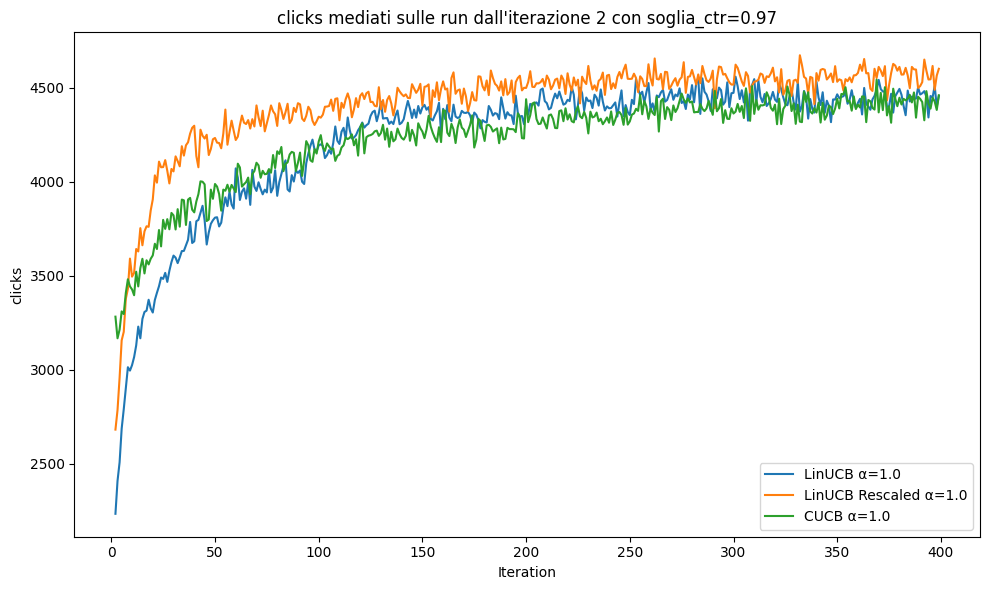

In [71]:
plot_mul_gr_soglia(models, iteration=1, quantity='clicks')

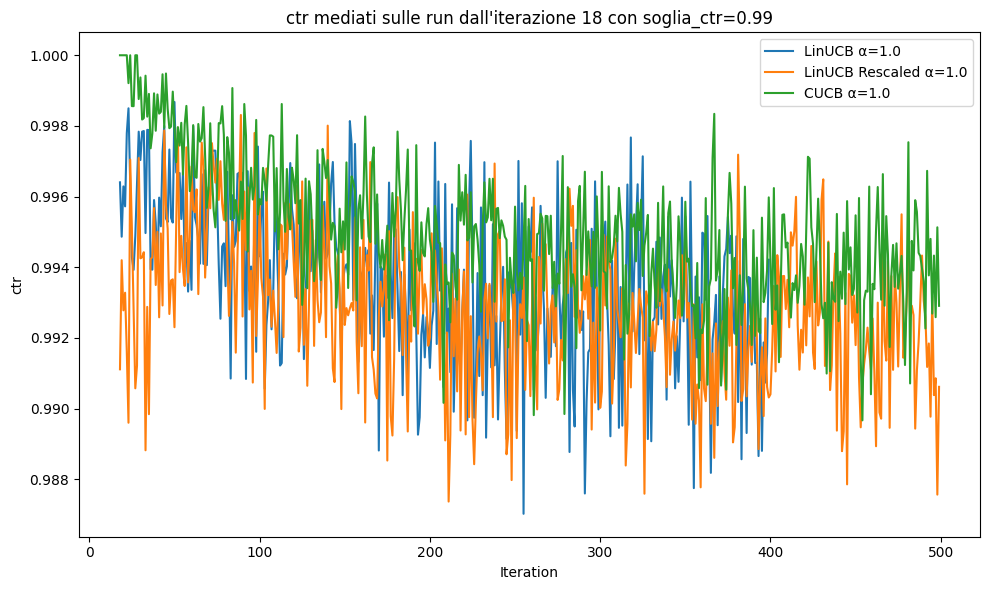

In [49]:
plot_mul_gr_soglia(models, iteration=17, quantity='ctr')

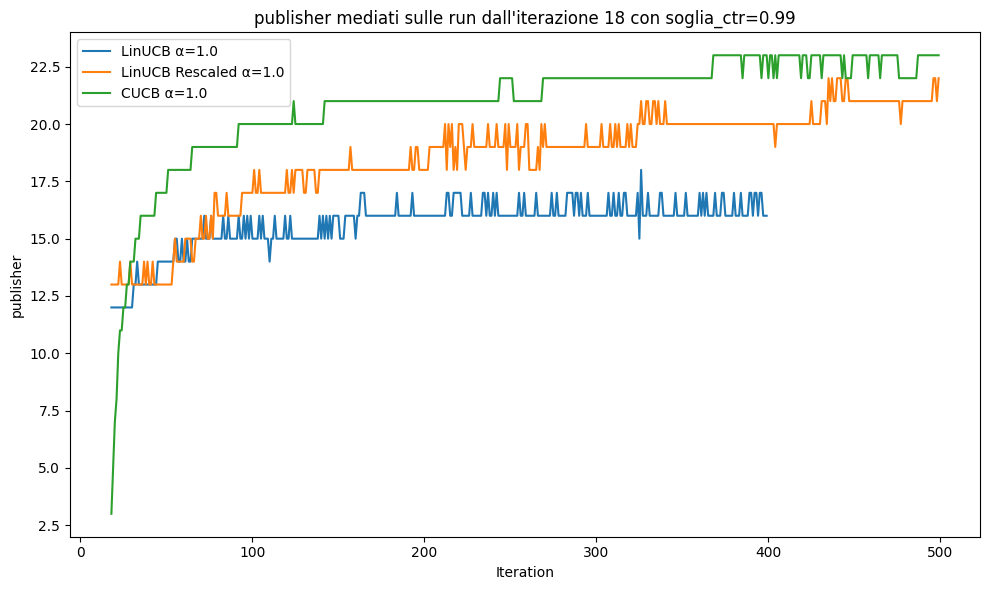

In [51]:
plot_mul_gr_soglia(models, iteration=17, quantity='publisher')

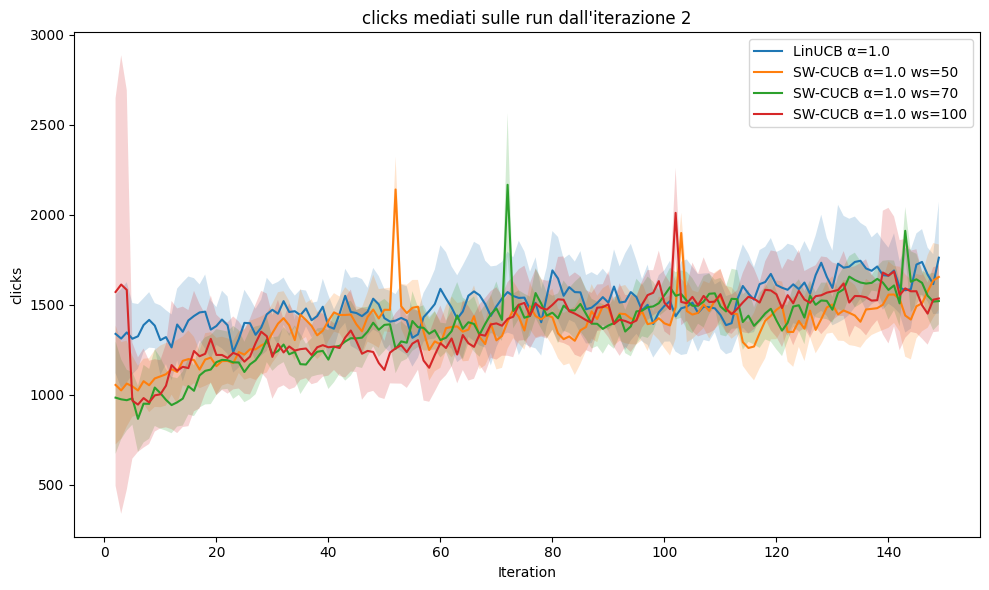

In [44]:
plot_mul_gr_sw(models, iteration=1, quantity='clicks')

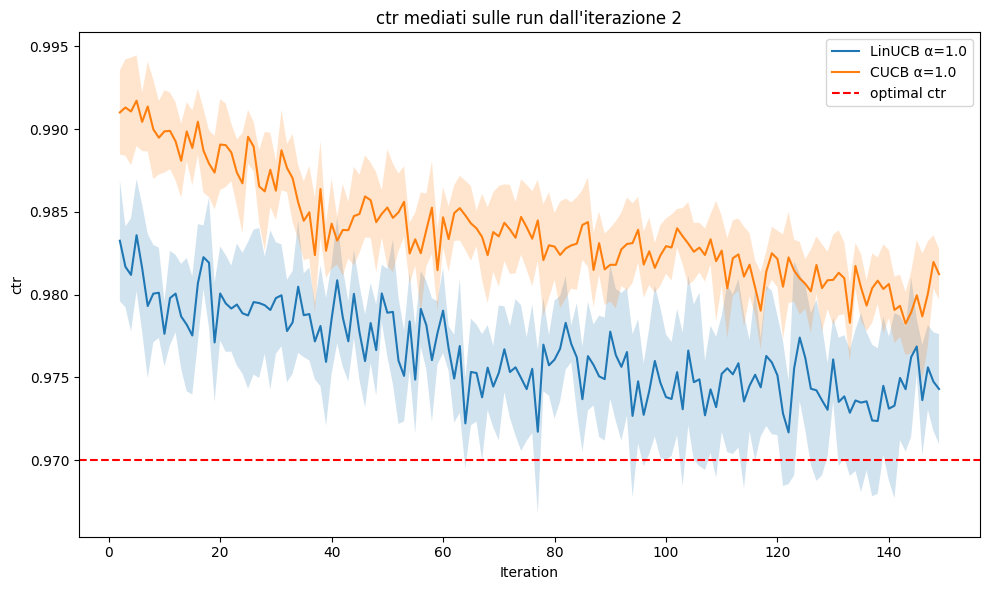

In [47]:
plot_mul_gr_sw(models, iteration=1, quantity='ctr', optimal_quantity=0.97)

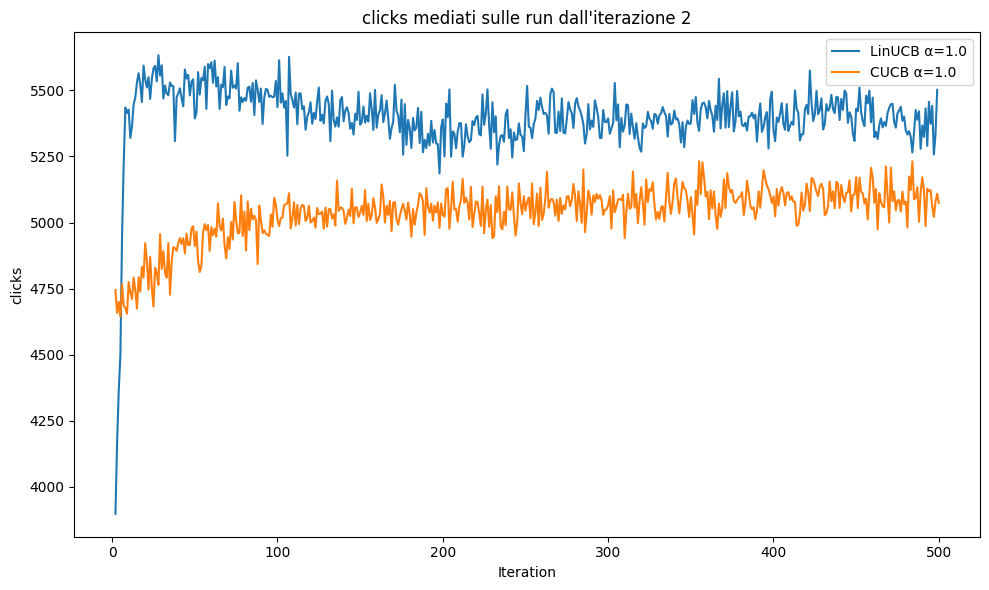

In [140]:
plot_mul_gr(models, iteration=1, quantity='clicks', alpha_to_exclude=[0])

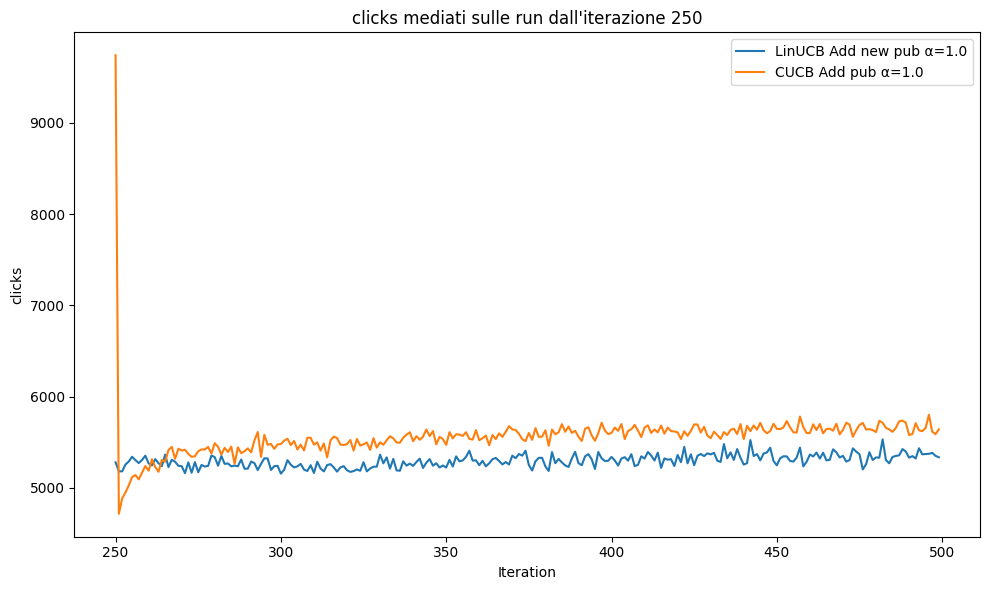

In [118]:
plot_mul_gr(models, iteration=249, quantity='clicks', alpha_to_exclude=[0])

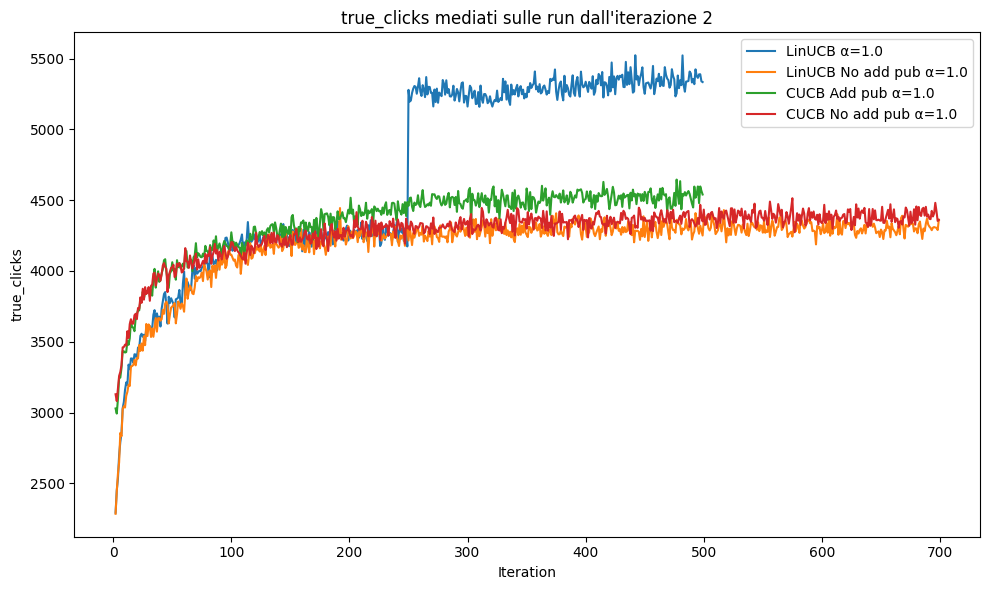

In [106]:
plot_mul_gr(models, iteration=1, quantity='true_clicks', alpha_to_exclude=[0])

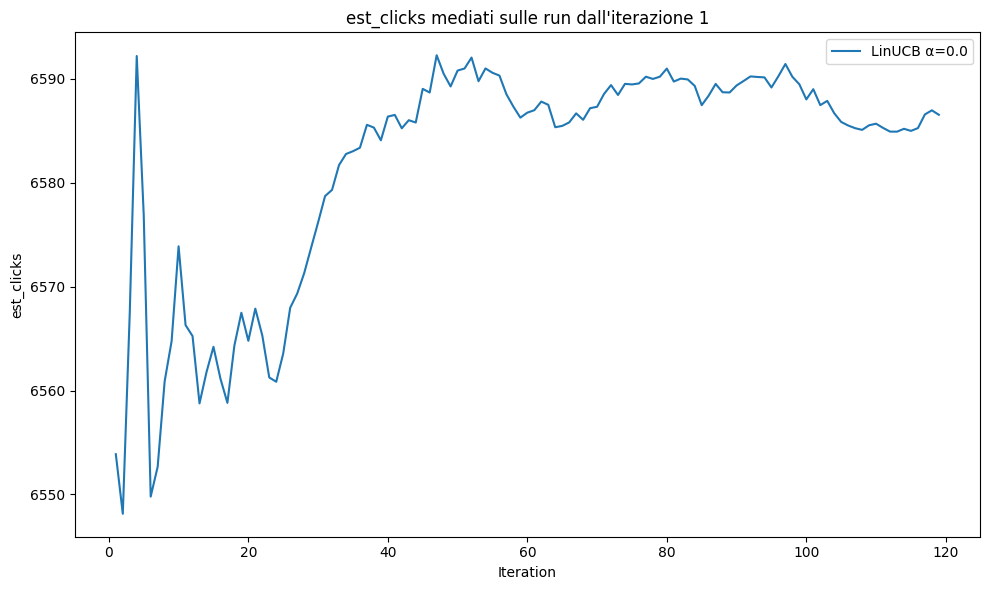

In [76]:
plot_mul_gr(models, iteration=0, quantity='est_clicks', alpha_to_exclude=[0.6, 1.0, 1.5])

In [60]:
alpha = 0
iteration = 0
model_data = linucb_gr_res[(linucb_gr_res['alpha'] == alpha)&(linucb_gr_res['Iteration'] > iteration)]
model_data['MAPE'] = np.abs(model_data['clicks'] - model_data['est_clicks']) / model_data['clicks']

/var/folders/pt/p9_0myf16lx1rjjrf63vkx5w0000gp/T/ipykernel_3446/2183668307.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  model_data['MAPE'] = np.abs(model_data['clicks'] - model_data['est_clicks']) / model_data['clicks']


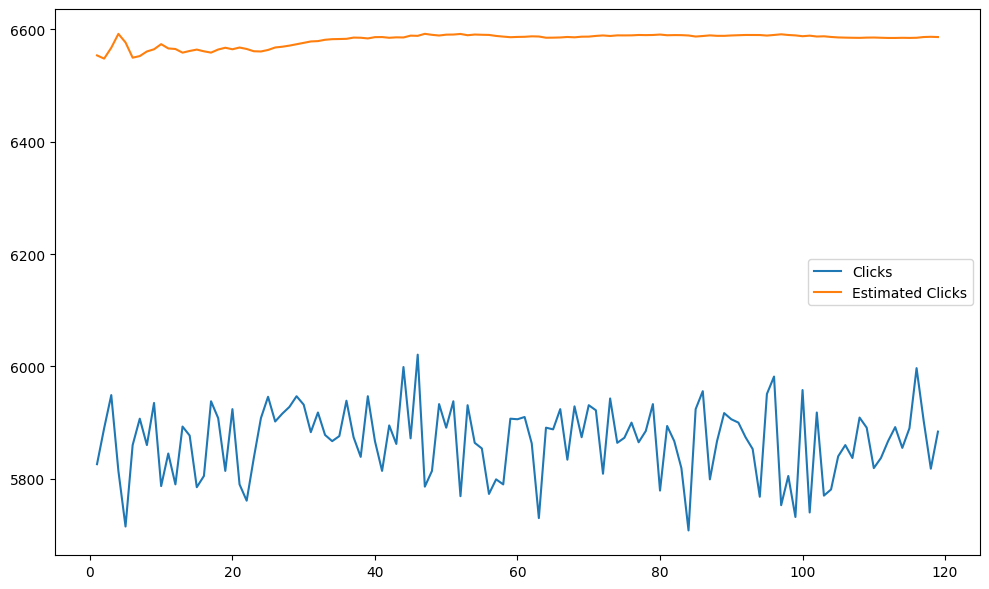

In [59]:
plt.figure(figsize=(10, 6))
plt.plot(model_data['Iteration'].to_numpy(), model_data['clicks'].to_numpy(), label=f'Clicks')
plt.plot(model_data['Iteration'].to_numpy(), model_data['est_clicks'].to_numpy(), label=f'Estimated Clicks')
plt.tight_layout()
plt.legend()
plt.show()

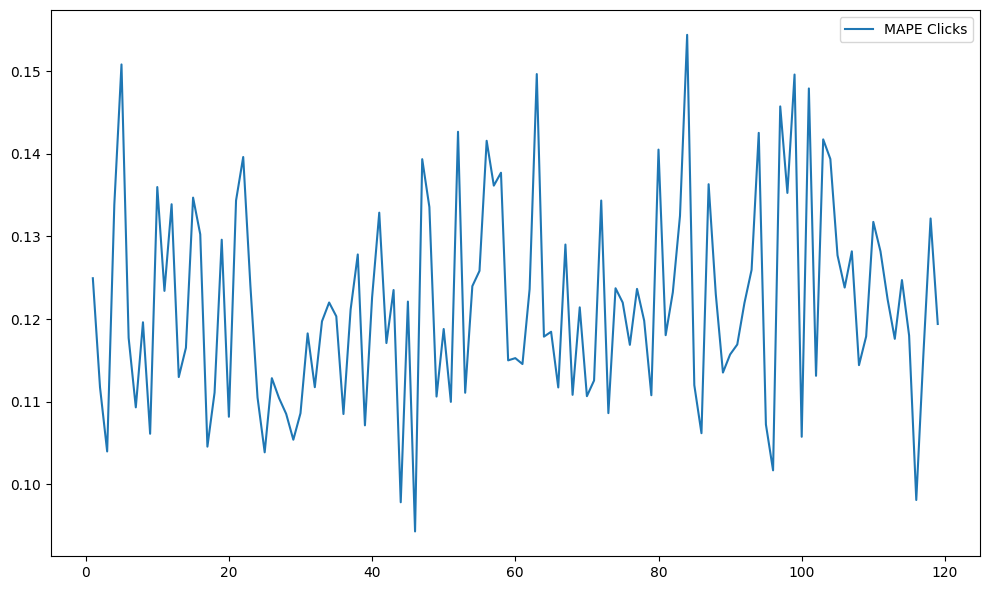

In [61]:
plt.figure(figsize=(10, 6))
plt.plot(model_data['Iteration'].to_numpy(), model_data['MAPE'].to_numpy(), label=f'MAPE Clicks')
plt.tight_layout()
plt.legend()
plt.show()

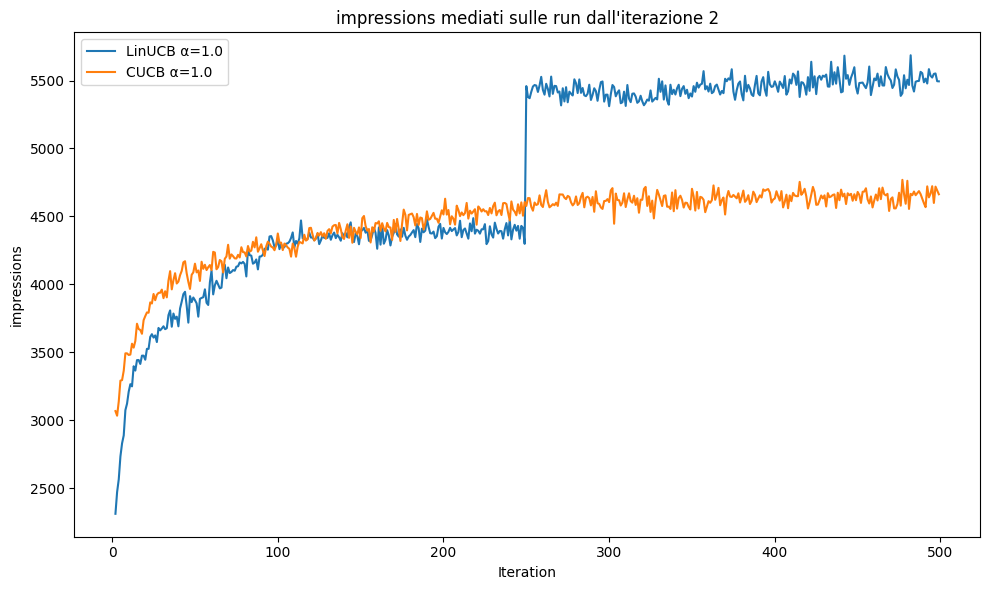

In [93]:
plot_mul_gr(models, iteration=1, quantity='impressions', alpha_to_exclude=[0.5, 1.2, 1.6, 2.0])

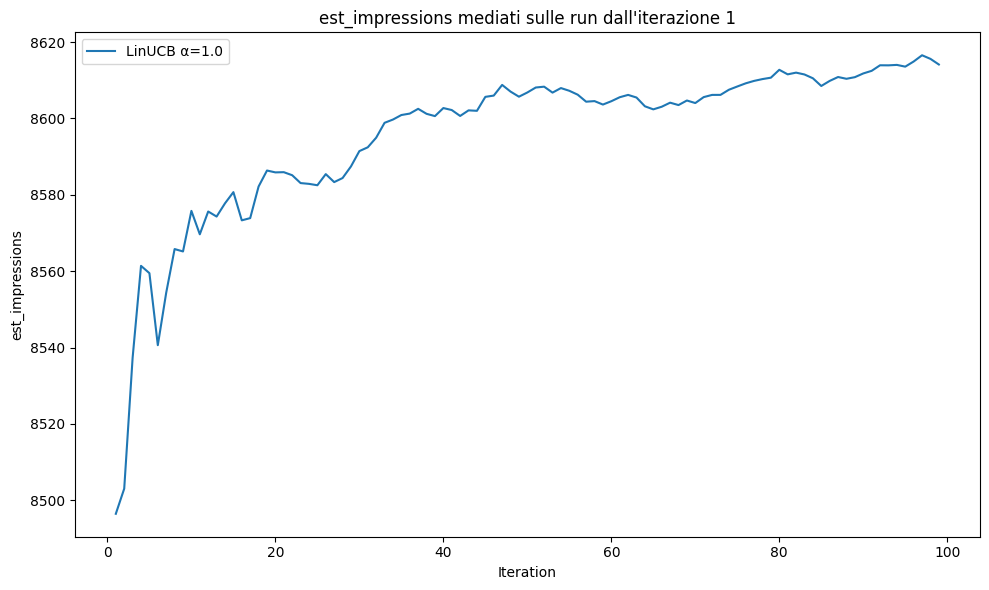

In [30]:
plot_mul_gr(models, iteration=0, quantity='est_impressions')

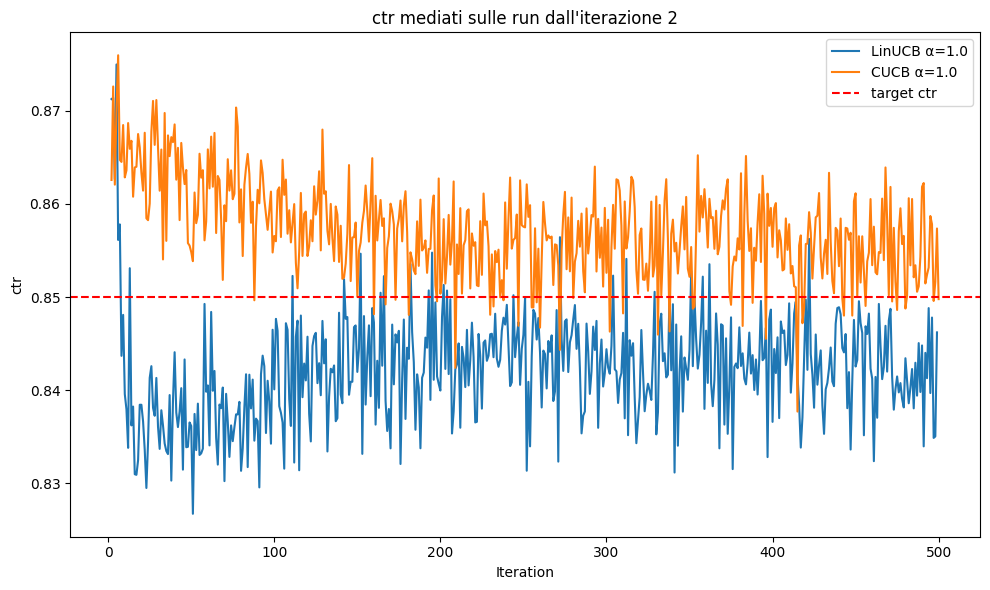

In [141]:
plot_mul_gr(models, iteration=1, quantity='ctr', alpha_to_exclude=[0], optimal_quantity=0.85)

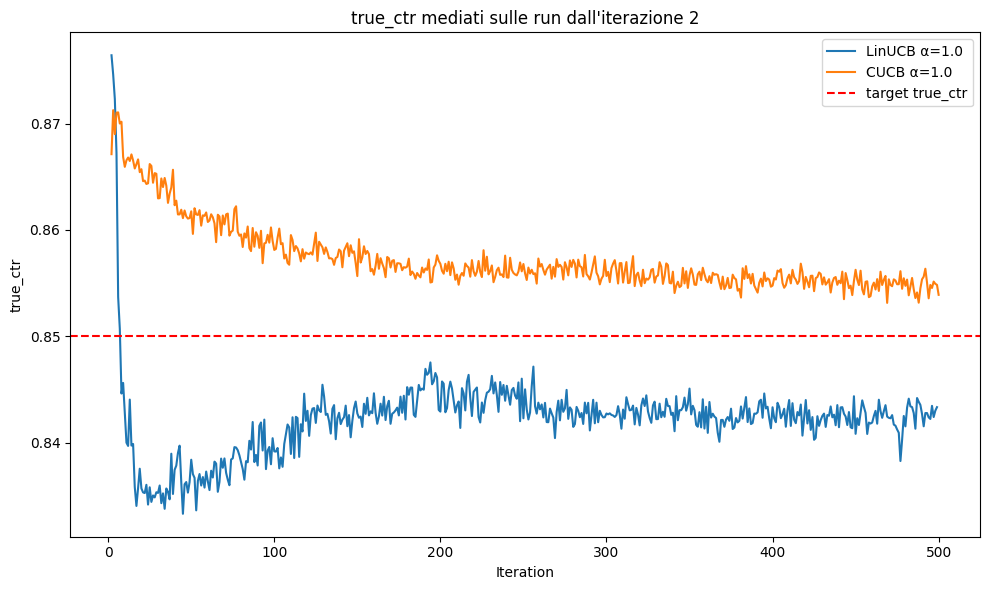

In [142]:
plot_mul_gr(models, iteration=1, quantity='true_ctr', alpha_to_exclude=[0], optimal_quantity=0.85)

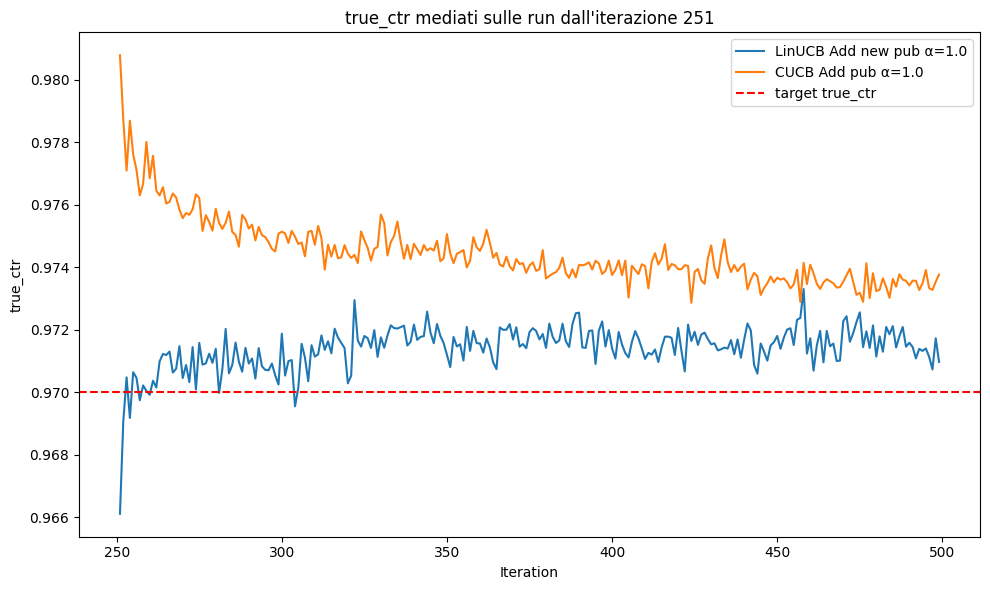

In [122]:
plot_mul_gr(models, iteration=250, quantity='true_ctr', alpha_to_exclude=[0], optimal_quantity=0.97)

In [37]:
def read_all_data(dir_path: str):
    # Load the results
    files_to_read = [file for file in os.listdir(dir_path) if file.endswith('.csv')]
    pattern = r'agent_stats_run_(\d+)_ctr_(\d+\.?\d*)_alpha_(\d+\.?\d*)'
    files_per_alpha = {}
    for file in files_to_read:
        match = re.search(pattern, file)
        if match:
            alpha = float(match.group(3))
            if alpha not in files_per_alpha:
                files_per_alpha[alpha] = [file]
            else:
                files_per_alpha[alpha].append(file)
    # Load the results
    results = pd.DataFrame()
    for alpha, files in files_per_alpha.items():
        for file in files:
            curr_results = pd.read_csv(dir_path + file)
            curr_results['alpha'] = alpha
            results = pd.concat([results, curr_results])
    return results

In [56]:
def get_pub_stats(results_df):
    stats_results = results_df[results_df['Iteration']>1].groupby(['alpha', 'Run', 'publisher']) \
        .size().reset_index(name='counts') \
        .sort_values(by='counts', ascending=False)    
    return stats_results

In [57]:
linucb_all_res = read_all_data(linucb_dir_path)

In [65]:
linucb_liscio_stats = get_pub_stats(linucb_all_res)
linucb_liscio_stats.head(20)

,alpha,Run,publisher,counts
15,1.0,0,leblogauto.com,398
2,1.0,0,autoruote4x4.com,398
22,1.0,0,turbo.fr,398
21,1.0,0,motoservices.com,398
5,1.0,0,coches.net,398
20,1.0,0,motociclismo.it,398
19,1.0,0,moto.it,398
18,1.0,0,moniteurautomobile.be,398
14,1.0,0,it.motor1.com,398
6,1.0,0,compta-facile.com,395


In [60]:
cucb_all_res = read_all_data(cucb_newagent_dir_path)

In [63]:
cucb_li_stats = get_pub_stats(cucb_all_res)
cucb_li_stats.head(20)

,alpha,Run,publisher,counts
200,1.0,0,motoservices.com,498
53,1.0,0,coches.net,498
107,1.0,0,formulapassion.it,498
270,1.0,0,turbo.fr,497
195,1.0,0,moniteurautomobile.be,497
164,1.0,0,leblogauto.com,496
146,1.0,0,it.motor1.com,496
199,1.0,0,motorsport.nextgen-auto.com,495
197,1.0,0,moto.it,494
198,1.0,0,motociclismo.it,494


In [64]:
linucb_rescaled_all_res = read_all_data(linucb_rescaled_dir_path)

linucb_rescaled_stats = get_pub_stats(linucb_rescaled_all_res)
linucb_rescaled_stats.head(20)

,alpha,Run,publisher,counts
23,1.0,0,motoservices.com,498
18,1.0,0,m.olx.pl,498
19,1.0,0,moniteurautomobile.be,498
14,1.0,0,it.motor1.com,498
20,1.0,0,moto.it,498
21,1.0,0,motociclismo.it,498
16,1.0,0,leblogauto.com,498
28,1.0,0,turbo.fr,498
3,1.0,0,borsaitaliana.it,498
11,1.0,0,formulapassion.it,495
